# 01 — Data Exploration

This notebook explores the ASL (American Sign Language) image dataset. It inspects class distributions, visualizes sample images per class, and examines pixel-level properties like color channels and edges.

## Imports

In [ ]:
import os
import cv2
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from pathlib import Path
import tensorflow as tf

from collections import Counter

import IPython

## Dataset Paths

In [9]:
TRAIN_DIR = Path("../data/processed/train")
VAL_DIR = Path("../data/processed/val")
TEST_DIR = Path("../data/processed/test")

## Classes

## Class Overview

Quick check of the number of classes and their names (used before the full path setup below).

In [10]:
classes = sorted([d.name for d in TRAIN_DIR.iterdir() if d.is_dir()])

print("Number of classes:", len(classes))
print(classes)

Number of classes: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


## Full Setup — Paths, Hyperparameters & Verification

Re-define paths using the notebook's working directory for portability. Also set global hyperparameters.

#### Distribution

In [ ]:

NOTEBOOK_DIR = Path(
    IPython.get_ipython().run_line_magic('pwd', '')
).resolve()

BASE_DIR = NOTEBOOK_DIR.parent / "data"

TRAIN_DIR = BASE_DIR / "processed" / "train"
VAL_DIR   = BASE_DIR / "processed" / "val"
TEST_DIR  = BASE_DIR / "processed" / "test"

OUT_DIR = NOTEBOOK_DIR.parent / "outputs"
OUT_DIR.mkdir(parents=True, exist_ok=True)



IMG_SIZE   = 128
BATCH_SIZE = 64

NUM_CLASSES = 29

AUTOTUNE = tf.data.AUTOTUNE

print("Train dir:", TRAIN_DIR)
print("Val dir  :", VAL_DIR)
print("Test dir :", TEST_DIR)
print("Output dir:", OUT_DIR)

assert TRAIN_DIR.exists(), "TRAIN_DIR not found"
assert VAL_DIR.exists(), "VAL_DIR not found"
assert TEST_DIR.exists(), "TEST_DIR not found"

Train dir: /media/bakhom-ramzy/Windows E/A-university/Sem-2/img-processing/SignLanguageTranslator/SignLanguageTranslator/project/data/processed/train
Val dir  : /media/bakhom-ramzy/Windows E/A-university/Sem-2/img-processing/SignLanguageTranslator/SignLanguageTranslator/project/data/processed/val
Test dir : /media/bakhom-ramzy/Windows E/A-university/Sem-2/img-processing/SignLanguageTranslator/SignLanguageTranslator/project/data/processed/test
Output dir: /media/bakhom-ramzy/Windows E/A-university/Sem-2/img-processing/SignLanguageTranslator/SignLanguageTranslator/project/outputs


### Class Names

In [ ]:
classes = sorted([
    d.name for d in TRAIN_DIR.iterdir()
    if d.is_dir()
])

print("Number of classes:", len(classes))
print(classes)

Number of classes: 29
['A', 'B', 'C', 'D', 'E', 'F', 'G', 'H', 'I', 'J', 'K', 'L', 'M', 'N', 'O', 'P', 'Q', 'R', 'S', 'T', 'U', 'V', 'W', 'X', 'Y', 'Z', 'del', 'nothing', 'space']


### Training Set — Class Distribution

Count the number of images per class in the training directory.

In [ ]:
counts = {}

for cls in classes:
    counts[cls] = len(list((TRAIN_DIR / cls).glob("*")))

print("Counts computed successfully")

Counts computed successfully


### Sample Images per Class

Display one representative image for each of the 29 classes.

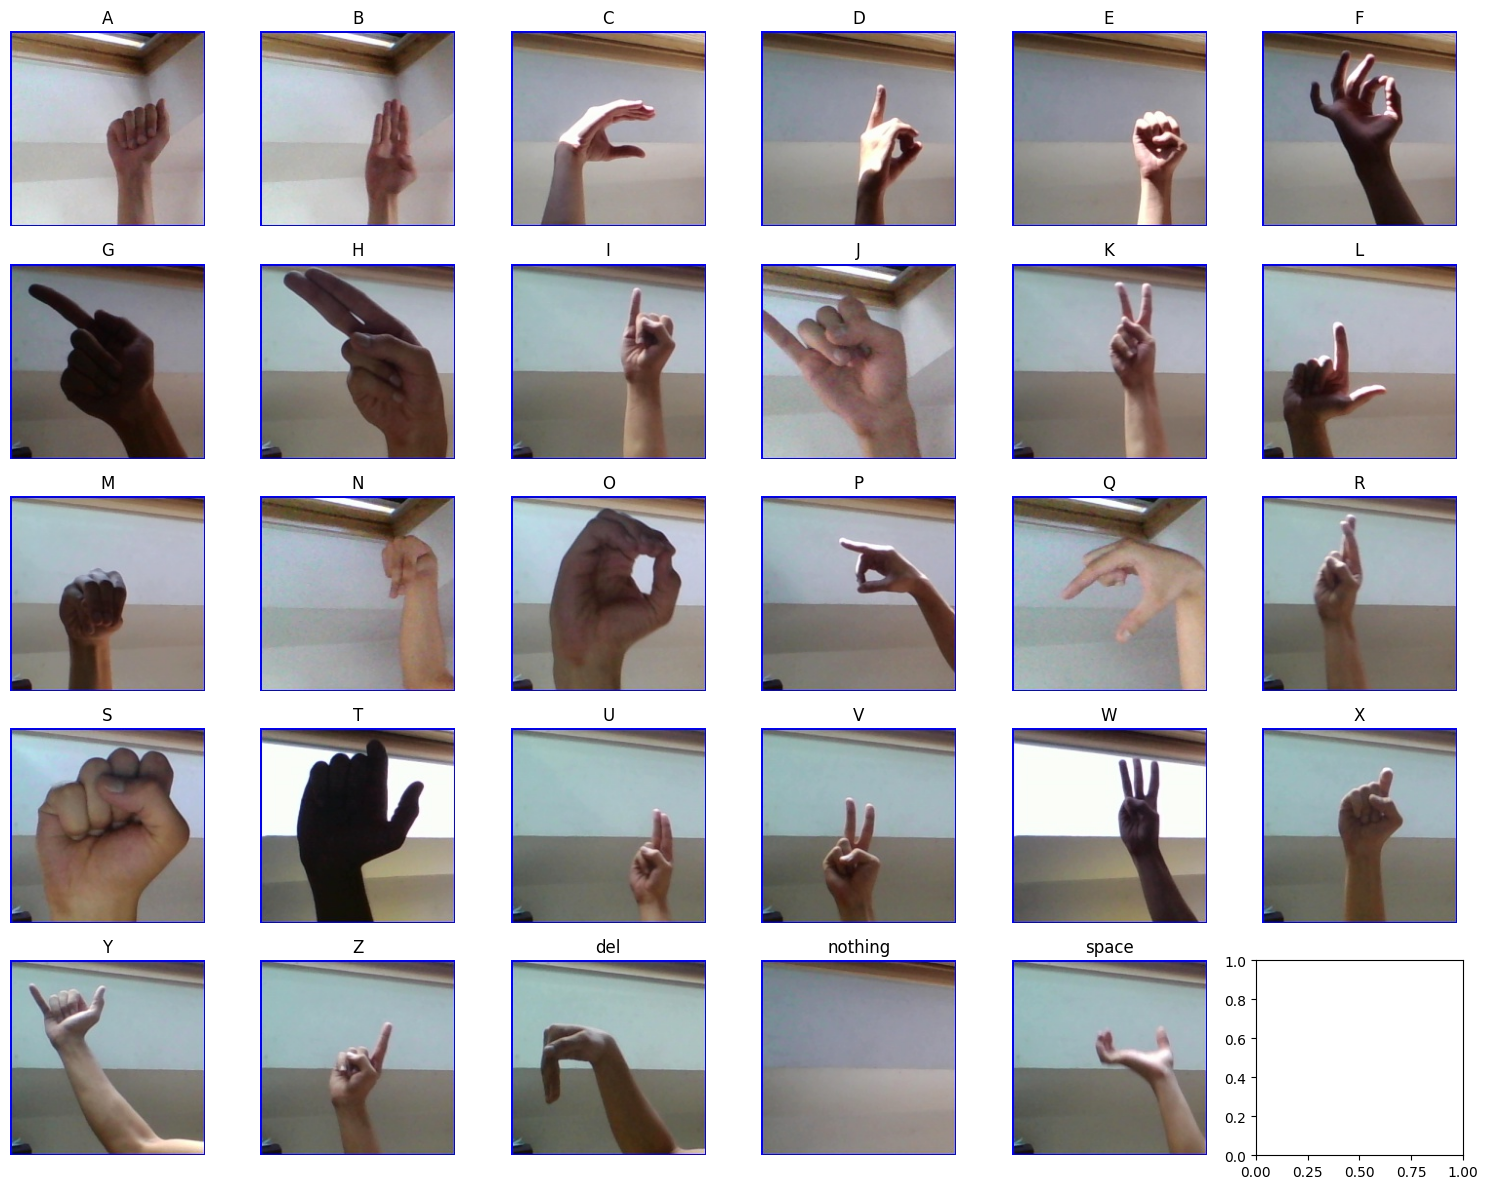

In [14]:
fig, axes = plt.subplots(5, 6, figsize=(15,12))

axes = axes.flatten()

for idx, cls in enumerate(classes):

    image_path = list((TRAIN_DIR / cls).glob("*"))[0]

    image = cv2.imread(str(image_path))

    image = cv2.cvtColor(image, cv2.COLOR_BGR2RGB)

    axes[idx].imshow(image)

    axes[idx].set_title(cls)

    axes[idx].axis("off")

plt.tight_layout()
plt.show()

### Image Shapes

Verify that all images share the same spatial dimensions.

In [15]:
shapes = []

for cls in classes:

    image_path = list((TRAIN_DIR / cls).glob("*"))[0]

    image = cv2.imread(str(image_path))

    shapes.append(image.shape)

set(shapes)

{(200, 200, 3)}

### RGB vs Grayscale Comparison

Visually compare a sample image in full color and grayscale.

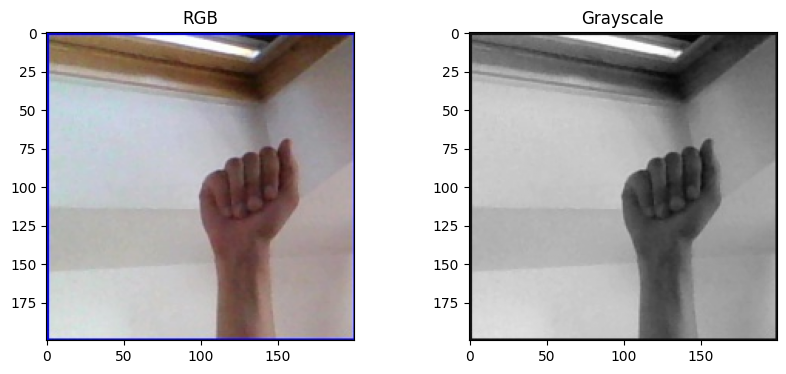

In [16]:
sample = list((TRAIN_DIR / "A").glob("*"))[0]

img = cv2.imread(str(sample))

rgb = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)

gray = cv2.cvtColor(img, cv2.COLOR_BGR2GRAY)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(rgb)
plt.title("RGB")

plt.subplot(1,2,2)
plt.imshow(gray, cmap='gray')
plt.title("Grayscale")

plt.show()

### Edge Detection (Canny)

Apply Canny edge detection to understand image structure and boundaries.

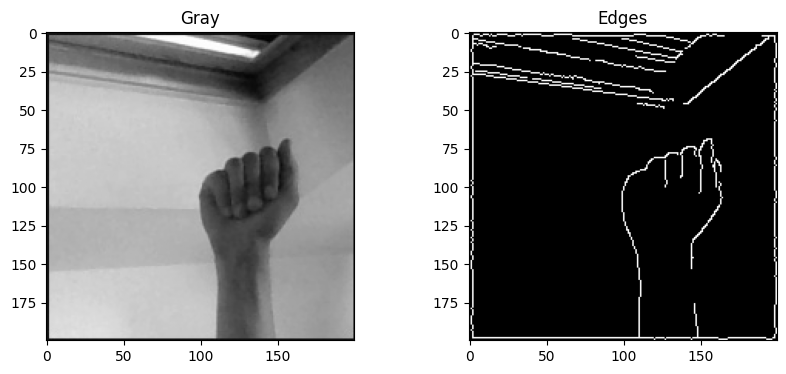

In [17]:
edges = cv2.Canny(gray, 100, 200)

plt.figure(figsize=(10,4))

plt.subplot(1,2,1)
plt.imshow(gray, cmap='gray')
plt.title("Gray")

plt.subplot(1,2,2)
plt.imshow(edges, cmap='gray')
plt.title("Edges")

plt.show()